# Imports and Configuration

In [3]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import GroupKFold, StratifiedKFold, StratifiedGroupKFold
from sklearn.metrics import roc_auc_score

# Models
import lightgbm as lgb
from lightgbm import early_stopping, log_evaluation
import xgboost as xgb
import catboost as cb
from catboost import CatBoostClassifier, Pool

# Utilities
from scipy.stats import rankdata
import gc
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Paths
COMP_PATH = "/kaggle/input/playground-series-s5e5"
ORIG_PATH = "/kaggle/input/f1-strategy-dataset-pit-stop-prediction"

TRAIN_PATH  = os.path.join(COMP_PATH, "train.csv")
TEST_PATH   = os.path.join(COMP_PATH, "test.csv")
SUB_PATH    = os.path.join(COMP_PATH, "sample_submission.csv")
ORIG_PATH_F = os.path.join(ORIG_PATH, "f1_strategy_dataset_v4.csv")

# Cross-Validation Config
N_FOLDS     = 5
TARGET      = "PitNextLap"
ORIG_WEIGHT = 0.7

# Softer compounds degrade faster → lower laps before pit
COMPOUND_ORDER = {
    "WET"          : 0,
    "INTERMEDIATE" : 1,
    "SOFT"         : 2,
    "MEDIUM"       : 3,
    "HARD"         : 4,
}

# LightGBM Params
LGB_PARAMS = {
    "objective"        : "binary",
    "metric"           : "auc",
    "learning_rate"    : 0.01,  
    "num_leaves"       : 127,
    "num_boost_round"  : 10000,
    "max_depth"        : -1,
    "min_child_samples": 100,
    "feature_fraction" : 0.7,   
    "bagging_fraction" : 0.7,   
    "bagging_freq"     : 1,
    "lambda_l1"        : 0.2,  
    "lambda_l2"        : 0.2,  
    "verbose"          : -1,
    "seed"             : SEED,
    "n_jobs"           : -1,
}

# XGBoost Params
XGB_PARAMS = {
    "objective"        : "binary:logistic",
    "eval_metric"      : "auc",
    "learning_rate"    : 0.05,
    "max_depth"        : 7,
    "min_child_weight" : 50,
    "subsample"        : 0.8,
    "colsample_bytree" : 0.8,
    "reg_alpha"        : 0.1,
    "reg_lambda"       : 0.1,
    "seed"             : SEED,
    "tree_method"      : "hist",
    "device"           : "cpu",
}

# CatBoost Params
CB_PARAMS = {
    "iterations"       : 2000,
    "learning_rate"    : 0.05,
    "depth"            : 7,
    "eval_metric"      : "AUC",
    "random_seed"      : SEED,
    "early_stopping_rounds": 100,
    "verbose"          : 200,
    "task_type"        : "CPU",
}

print("All imports loaded successfully.")
print(f"   LightGBM  v{lgb.__version__}")
print(f"   XGBoost   v{xgb.__version__}")
print(f"   CatBoost  v{cb.__version__}")

All imports loaded successfully.
   LightGBM  v4.6.0
   XGBoost   v3.2.0
   CatBoost  v1.2.10


# Load Data + Merge Original

In [4]:
# Load Competition Files
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e5/train.csv')
test  = pd.read_csv('/kaggle/input/competitions/playground-series-s6e5/test.csv')
sub   = pd.read_csv('/kaggle/input/competitions/playground-series-s6e5/sample_submission.csv')

print(f"Train shape : {train.shape}")
print(f"Test  shape : {test.shape}")

# Load Original Dataset
orig = pd.read_csv('/kaggle/input/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction/f1_strategy_dataset_v4.csv')
print(f"Orig  shape (raw) : {orig.shape}")

# Align Original to Competition Schema
orig.drop(columns=["Normalized_TyreLife"], inplace=True, errors="ignore")
orig["id"] = -1
orig = orig[[c for c in train.columns if c in orig.columns]]

# Compound has NaN rows — drop them, then cast to str
print(f"\nOrig nulls before clean :\n{orig.isnull().sum()[orig.isnull().sum() > 0]}")

orig.dropna(subset=["Compound"], inplace=True)
orig["Compound"] = orig["Compound"].astype(str).str.strip().str.upper()

# Cast all string columns to consistent str type
for col in ["Driver", "Race", "Compound"]:
    orig[col]  = orig[col].astype(str).str.strip()
    train[col] = train[col].astype(str).str.strip()
    test[col]  = test[col].astype(str).str.strip()

print(f"Orig  shape (clean) : {orig.shape}")

print(f"\nCompound values — Train : {sorted(train['Compound'].unique())}")
print(f"Compound values — Orig  : {sorted(orig['Compound'].unique())}")
print(f"\nYear range — Train : {train['Year'].min()}–{train['Year'].max()}")
print(f"Year range — Orig  : {orig['Year'].min()}–{orig['Year'].max()}")

print("\n── Target Distribution ──")
print(f"  Train : {train[TARGET].value_counts(normalize=True).round(3).to_dict()}")
print(f"  Orig  : {orig[TARGET].value_counts(normalize=True).round(3).to_dict()}")

train["is_orig"] = 0
orig["is_orig"]  = 1

# Combine Train + Original
all_train = pd.concat([train, orig], axis=0, ignore_index=True)

print(f"\nCombined train shape  : {all_train.shape}")
print(f"Competition rows : {(all_train['is_orig']==0).sum():,}")
print(f"Original rows    : {(all_train['is_orig']==1).sum():,}")

all_train["sample_weight"] = np.where(
    all_train["is_orig"] == 1, ORIG_WEIGHT, 1.0
)

print(f"\nMissing values in all_train : {all_train.isnull().sum().sum()}")
print(f"Missing values in test      : {test.isnull().sum().sum()}")

print("\nData loaded and merged successfully.")

Train shape : (439140, 16)
Test  shape : (188165, 15)
Orig  shape (raw) : (101371, 16)

Orig nulls before clean :
Compound    66
dtype: int64
Orig  shape (clean) : (101305, 16)

Compound values — Train : ['HARD', 'INTERMEDIATE', 'MEDIUM', 'SOFT', 'WET']
Compound values — Orig  : ['HARD', 'INTERMEDIATE', 'MEDIUM', 'SOFT', 'WET']

Year range — Train : 2022–2025
Year range — Orig  : 2022–2025

── Target Distribution ──
  Train : {0.0: 0.801, 1.0: 0.199}
  Orig  : {0: 0.745, 1: 0.255}

Combined train shape  : (540445, 17)
Competition rows : 439,140
Original rows    : 101,305

Missing values in all_train : 0
Missing values in test      : 0

Data loaded and merged successfully.


In [5]:
#  PSEUDO LABELING
v4_preds = pd.read_csv("/kaggle/input/datasets/shamanthakreddymallu/my-v10-submission/submission.csv")

# Merge predictions onto test set
test_with_preds = test.merge(v4_preds, on="id")
print(f"Test rows          : {len(test_with_preds)}")

HIGH_CONF_PIT    = 0.90   # very likely pitting
LOW_CONF_PIT     = 0.05   # very likely NOT pitting

mask_pit    = test_with_preds["PitNextLap"] >= HIGH_CONF_PIT
mask_nopit  = test_with_preds["PitNextLap"] <= LOW_CONF_PIT

pseudo_pit   = test_with_preds[mask_pit].copy()
pseudo_nopit = test_with_preds[mask_nopit].copy()

print(f"\nHigh confidence PIT rows    : {len(pseudo_pit):,}  (prob >= {HIGH_CONF_PIT})")
print(f"High confidence NO-PIT rows : {len(pseudo_nopit):,}  (prob <= {LOW_CONF_PIT})")

# Assign hard labels
pseudo_pit["PitNextLap"]   = 1.0
pseudo_nopit["PitNextLap"] = 0.0

# ddCombine
pseudo_all = pd.concat([pseudo_pit, pseudo_nopit], axis=0)
pseudo_all["is_orig"]       = 0
pseudo_all["sample_weight"] = 0.6   # discounted — not real labels

print(f"Total pseudo rows           : {len(pseudo_all):,}")
print(f"Pseudo pit rate             : {pseudo_all['PitNextLap'].mean():.3f}")

# all_train already has competition + original rows from Cell 2
all_train = pd.concat([all_train, pseudo_all], axis=0, ignore_index=True)

print(f"\nCombined training set:")
print(f"  Competition rows : {(all_train['is_orig']==0).sum():,}")
print(f"  Original rows    : {(all_train['is_orig']==1).sum():,}")
print(f"  Pseudo rows      : {len(pseudo_all):,}")
print(f"  Total            : {len(all_train):,}")
print(f"\n Pseudo-labeling complete")

Test rows          : 188165

High confidence PIT rows    : 18,780  (prob >= 0.9)
High confidence NO-PIT rows : 7,574  (prob <= 0.05)
Total pseudo rows           : 26,354
Pseudo pit rate             : 0.713

Combined training set:
  Competition rows : 465,494
  Original rows    : 101,305
  Pseudo rows      : 26,354
  Total            : 566,799

 Pseudo-labeling complete


# Feature Engineering

In [6]:
# Mark test rows, concat
test["is_orig"]       = 0
test["sample_weight"] = 1.0
test[TARGET]          = np.nan

combined = pd.concat([all_train, test], axis=0, ignore_index=True)
print(f"Combined (train+test) shape: {combined.shape}")

Combined (train+test) shape: (754964, 18)


## Compound Ordinal Encoding

In [7]:
combined["Compound_ord"] = combined["Compound"].map(COMPOUND_ORDER)

## Race + Year Group Key

In [8]:
combined["RaceYear"] = combined["Race"] + "_" + combined["Year"].astype(str)

## Total Laps per Race (derived from RaceProgress)

In [9]:
combined["TotalLaps_est"] = (
    combined["LapNumber"] / combined["RaceProgress"].replace(0, np.nan)
).round()

combined["LapsRemaining"] = combined["TotalLaps_est"] - combined["LapNumber"]

## Tyre × Compound Interaction

In [10]:
# 15 laps on SOFT ≠ 15 laps on HARD
combined["TyreLife_x_Compound"] = combined["TyreLife"] * combined["Compound_ord"]

# Expected max stint length per compound (domain knowledge)
COMPOUND_MAX_STINT = {
    "SOFT"         : 25,
    "MEDIUM"       : 35,
    "HARD"         : 50,
    "INTERMEDIATE" : 30,
    "WET"          : 40,
}
combined["MaxStint"] = combined["Compound"].map(COMPOUND_MAX_STINT)
combined["TyrePct_Used"] = combined["TyreLife"] / combined["MaxStint"]  # 0→1+ scale
combined["TyrePct_Used"] = combined["TyrePct_Used"].clip(0, 2)          # cap outliers

## Race Stage Flags

In [11]:
combined["IsEarlyRace"]  = (combined["RaceProgress"] < 0.25).astype(int)
combined["IsMidRace"]    = ((combined["RaceProgress"] >= 0.25) &
                            (combined["RaceProgress"] < 0.70)).astype(int)
combined["IsLateRace"]   = (combined["RaceProgress"] >= 0.70).astype(int)

# Undercut window: laps 20-40% and 55-75% are classic pit windows
combined["InPitWindow"]  = (
    ((combined["RaceProgress"] >= 0.20) & (combined["RaceProgress"] <= 0.40)) |
    ((combined["RaceProgress"] >= 0.55) & (combined["RaceProgress"] <= 0.75))
).astype(int)

## Stint Number as Pit Count Proxy

In [12]:
combined["StopsAlready"]   = combined["Stint"] - 1
combined["Is1Stopper"]     = (combined["Stint"] == 1).astype(int)  # likely to pit once more# 

## Interaction Features

In [13]:
# Sort by driver + race + lap so rolling windows are temporal
combined.sort_values(["Driver", "RaceYear", "LapNumber"], inplace=True)
combined.reset_index(drop=True, inplace=True)

grp = combined.groupby(["Driver", "RaceYear"])

# Old tyres + late race = THE core pit trigger
combined["TyreLife_x_RaceProgress"] = (
    combined["TyreLife"] * combined["RaceProgress"]
)

# How fast are tyres degrading per lap?
combined["Degradation_per_Lap"] = (
    combined["Cumulative_Degradation"] / combined["TyreLife"].replace(0, 1)
).clip(0, 10)

# Strategic ratio: can we physically make it to the end?
combined["TyreLife_vs_LapsRemaining"] = (
    combined["TyreLife"] / combined["LapsRemaining"].replace(0, 1)
).clip(0, 10)

# Binary: tyres last longer than laps remaining → no pit needed
combined["CanMakeItToEnd"] = (
    combined["TyreLife"] >= combined["LapsRemaining"]
).astype(int)

# Stint aggression: high stint number on soft compound = dangerous
combined["Stint_x_Compound"] = combined["Stint"] * combined["Compound_ord"]

# Raw distance to optimal stint end
combined["LapsOverMaxStint"] = (
    combined["TyreLife"] - combined["MaxStint"]
).clip(-50, 50)

## Group-Based Rolling Features

In [14]:
# Rolling 3-lap mean of LapTime — smoothed pace
combined["LapTime_roll3"]  = (
    grp["LapTime (s)"].transform(lambda x: x.rolling(3, min_periods=1).mean())
)

# Rolling 3-lap mean of LapTime_Delta — degradation trend
combined["Delta_roll3"]    = (
    grp["LapTime_Delta"].transform(lambda x: x.rolling(3, min_periods=1).mean())
)

# Rolling 3-lap mean of Cumulative_Degradation
combined["CumDeg_roll3"]   = (
    grp["Cumulative_Degradation"].transform(lambda x: x.rolling(3, min_periods=1).mean())
)

# Lap-over-lap LapTime change (sudden slowdown = tyre cliff)
combined["LapTime_diff1"]  = (
    grp["LapTime (s)"].transform(lambda x: x.diff(1))
)

## Extended Rolling Windows

In [15]:
combined["LapTime_roll5"]  = (
    grp["LapTime (s)"].transform(lambda x: x.rolling(5,  min_periods=1).mean())
)
combined["Delta_roll5"]    = (
    grp["LapTime_Delta"].transform(lambda x: x.rolling(5,  min_periods=1).mean())
)
combined["LapTime_roll10"] = (
    grp["LapTime (s)"].transform(lambda x: x.rolling(10, min_periods=1).mean())
)
combined["Delta_roll10"]   = (
    grp["LapTime_Delta"].transform(lambda x: x.rolling(10, min_periods=1).mean())
)

# Pace dropoff: recent 3-lap avg vs longer 10-lap avg
# Positive value = getting slower = tyre cliff signal
combined["PaceDropoff_3v10"] = (
    combined["LapTime_roll3"] - combined["LapTime_roll10"]
)
combined["DegDropoff_3v10"]  = (
    combined["Delta_roll3"] - combined["Delta_roll10"]
)

## Position-Based Features

In [16]:
combined["InPoints"]        = (combined["Position"] <= 10).astype(int)
combined["TopFive"]         = (combined["Position"] <= 5).astype(int)
combined["Position_x_Lap"]  = combined["Position"] * combined["RaceProgress"]

## Label Encoding for Categorical Columns

In [17]:
LE_COLS = ["Driver", "Race", "Compound", "RaceYear"]
le_dict = {}
for col in LE_COLS:
    le = LabelEncoder()
    combined[f"LE_{col}"] = le.fit_transform(combined[col].astype(str))
    le_dict[col] = le

print("Label encoding done for:", [f"LE_{c}" for c in LE_COLS])

Label encoding done for: ['LE_Driver', 'LE_Race', 'LE_Compound', 'LE_RaceYear']


## Fill any NaNs created by rolling/diff

In [18]:
roll_cols = [
    "LapTime_roll3", "Delta_roll3", "CumDeg_roll3", "LapTime_diff1",
    "LapTime_roll5", "Delta_roll5", "LapTime_roll10", "Delta_roll10",
    "PaceDropoff_3v10", "DegDropoff_3v10",
    "TotalLaps_est", "LapsRemaining",
    "Degradation_per_Lap", "TyreLife_vs_LapsRemaining",
    "LapsOverMaxStint",
]
combined[roll_cols] = combined[roll_cols].fillna(0)

## Split back into train / test

In [21]:
train_fe = combined[combined[TARGET].notna()].copy()
test_fe  = combined[combined[TARGET].isna()].copy()

print(f"\ntrain_fe shape : {train_fe.shape}")
print(f"test_fe  shape : {test_fe.shape}")


train_fe shape : (566799, 54)
test_fe  shape : (188165, 54)


## Target Encoding

In [22]:
TARGET_ENC_COLS = ["Driver", "Race", "RaceYear", "Compound"]
SMOOTH = 20
global_mean = train_fe[TARGET].mean()

# Initialize columns
for col in TARGET_ENC_COLS:
    train_fe[f"TE_{col}"] = 0.0
    test_fe[f"TE_{col}"] = 0.0

temp_sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

for tr_idx, val_idx in temp_sgkf.split(train_fe, train_fe[TARGET], train_fe["RaceYear"]):
    tr_df = train_fe.iloc[tr_idx]
    val_df = train_fe.iloc[val_idx]
    
    for col in TARGET_ENC_COLS:
        agg = tr_df.groupby(col)[TARGET].agg(["mean", "count"])
        agg["te_smooth"] = (agg["count"] * agg["mean"] + SMOOTH * global_mean) / (agg["count"] + SMOOTH)
        
        # Map to validation fold
        train_fe.loc[train_fe.index[val_idx], f"TE_{col}"] = val_df[col].map(agg["te_smooth"]).fillna(global_mean)
        
        # Map to test set (accumulating across folds)
        test_fe[f"TE_{col}"] += test_fe[col].map(agg["te_smooth"]).fillna(global_mean) / N_FOLDS

print("Proper OOF Target Encoding complete.")

Proper OOF Target Encoding complete.


## Features

In [23]:
FEATURES = [
    # Raw numerics
    "Year", "LapNumber", "Stint", "TyreLife", "Position",
    "LapTime (s)", "LapTime_Delta", "Cumulative_Degradation",
    "RaceProgress", "Position_Change", "PitStop",
    # Tyre features
    "Compound_ord", "TyreLife_x_Compound", "TyrePct_Used", "MaxStint",
    "TotalLaps_est", "LapsRemaining",
    # Interaction features
    "TyreLife_x_RaceProgress", "Degradation_per_Lap",
    "TyreLife_vs_LapsRemaining", "CanMakeItToEnd",
    "Stint_x_Compound", "LapsOverMaxStint",
    # Race stage
    "IsEarlyRace", "IsMidRace", "IsLateRace", "InPitWindow",
    "StopsAlready", "Is1Stopper",
    # Rolling windows
    "LapTime_roll3", "Delta_roll3", "CumDeg_roll3", "LapTime_diff1",
    "LapTime_roll5", "Delta_roll5",
    "LapTime_roll10", "Delta_roll10",
    "PaceDropoff_3v10", "DegDropoff_3v10",
    # Position
    "InPoints", "TopFive", "Position_x_Lap",
    # Encodings
    "LE_Driver", "LE_Race", "LE_Compound", "LE_RaceYear",
    "TE_Driver", "TE_Race", "TE_Compound", "TE_RaceYear",
]  

print(f"\nTotal features: {len(FEATURES)}")


Total features: 50


## Null Check

In [24]:
null_check = train_fe[FEATURES].isnull().sum()
if null_check.sum() == 0:
    print("\nNo nulls in feature matrix.")
else:
    print("\nNulls found:")
    print(null_check[null_check > 0])


No nulls in feature matrix.


# Cross-validation + LightGBM

  LightGBM — 5-Fold GroupKFold (by Year — one season per fold)
[500]	valid_0's auc: 0.950362
[1000]	valid_0's auc: 0.951981
[1500]	valid_0's auc: 0.952447
[2000]	valid_0's auc: 0.952632

  Fold 1 │ AUC: 0.95274 │ Best iter: 2309
[500]	valid_0's auc: 0.937399
[1000]	valid_0's auc: 0.940425
[1500]	valid_0's auc: 0.941178

  Fold 2 │ AUC: 0.94143 │ Best iter: 1793
[500]	valid_0's auc: 0.936255
[1000]	valid_0's auc: 0.938024
[1500]	valid_0's auc: 0.938528
[2000]	valid_0's auc: 0.938859
[2500]	valid_0's auc: 0.939023

  Fold 3 │ AUC: 0.93904 │ Best iter: 2552
[500]	valid_0's auc: 0.935688
[1000]	valid_0's auc: 0.937891
[1500]	valid_0's auc: 0.938533
[2000]	valid_0's auc: 0.938696

  Fold 4 │ AUC: 0.93881 │ Best iter: 2266
[500]	valid_0's auc: 0.903065
[1000]	valid_0's auc: 0.906339
[1500]	valid_0's auc: 0.907266
[2000]	valid_0's auc: 0.907846
[2500]	valid_0's auc: 0.90812

  Fold 5 │ AUC: 0.90824 │ Best iter: 2620

  LightGBM OOF AUC : 0.93436
  Per-fold AUCs    : [np.float64(0.95274), np.f

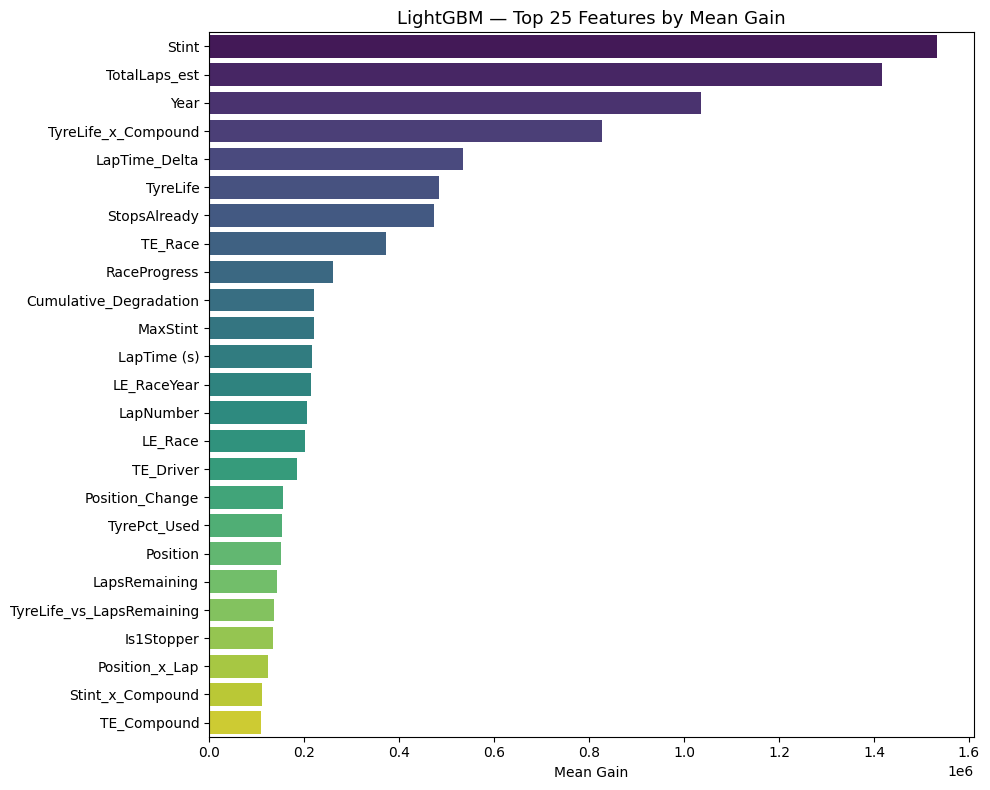


LightGBM training complete.
   OOF array  shape : (566799,)
   Test preds shape : (188165,)


In [25]:
X      = train_fe[FEATURES].values
y      = train_fe[TARGET].values.astype(int)
w      = train_fe["sample_weight"].values
groups = train_fe["RaceYear"].values 

X_test = test_fe[FEATURES].values

oof_lgb  = np.zeros(len(X))                  # out-of-fold predictions
test_lgb = np.zeros(len(X_test))             # averaged test predictions
fold_auc = []
feature_importance_list = []

sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

print("=" * 60)
print(f"  LightGBM — {N_FOLDS}-Fold GroupKFold (by Year — one season per fold)")
print("=" * 60)

for fold, (tr_idx, val_idx) in enumerate(sgkf.split(X, y, groups), 1):

    X_tr, X_val = X[tr_idx], X[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]
    w_tr        = w[tr_idx]

    dtrain = lgb.Dataset(X_tr, label=y_tr, weight=w_tr,
                         feature_name=FEATURES)
    dvalid = lgb.Dataset(X_val, label=y_val,
                         feature_name=FEATURES, reference=dtrain)

    model = lgb.train(
        LGB_PARAMS,   
        dtrain,
        num_boost_round        = 8000,
        valid_sets             = [dvalid],
        callbacks              = [
            early_stopping(stopping_rounds=150, verbose=False),
            log_evaluation(period=500),
        ],
    )

    oof_lgb[val_idx] = model.predict(X_val)
    test_lgb += model.predict(X_test) / N_FOLDS

    auc = roc_auc_score(y_val, oof_lgb[val_idx])
    fold_auc.append(auc)
    print(f"\n  Fold {fold} │ AUC: {auc:.5f} │ "
          f"Best iter: {model.best_iteration}")

    fi = pd.DataFrame({
        "feature"   : FEATURES,
        "importance": model.feature_importance(importance_type="gain"),
        "fold"      : fold,
    })
    feature_importance_list.append(fi)

    del X_tr, X_val, y_tr, y_val, dtrain, dvalid
    gc.collect()

oof_auc_lgb = roc_auc_score(y, oof_lgb)

print("\n" + "=" * 60)
print(f"  LightGBM OOF AUC : {oof_auc_lgb:.5f}")
print(f"  Per-fold AUCs    : {[round(a,5) for a in fold_auc]}")
print(f"  Std dev          : {np.std(fold_auc):.5f}")
print("=" * 60)

# Feature Importance Plot
fi_df = (
    pd.concat(feature_importance_list)
    .groupby("feature")["importance"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 8))
sns.barplot(data=fi_df.head(25), x="importance", y="feature",
            palette="viridis")
plt.title("LightGBM — Top 25 Features by Mean Gain", fontsize=13)
plt.xlabel("Mean Gain")
plt.ylabel("")
plt.tight_layout()
plt.show()

print("\nLightGBM training complete.")
print(f"   OOF array  shape : {oof_lgb.shape}")
print(f"   Test preds shape : {test_lgb.shape}")

# XGBoost

  XGBoost — 5-Fold GroupKFold (by Year — one season per fold)
[0]	val-auc:0.92588
[200]	val-auc:0.94918
[400]	val-auc:0.94964
[464]	val-auc:0.94951

  Fold 1 │ AUC: 0.94951 │ Best iter: 364
[0]	val-auc:0.86365
[200]	val-auc:0.93803
[400]	val-auc:0.93950
[510]	val-auc:0.93939

  Fold 2 │ AUC: 0.93939 │ Best iter: 410
[0]	val-auc:0.90048
[200]	val-auc:0.93561
[400]	val-auc:0.93651
[600]	val-auc:0.93739
[800]	val-auc:0.93768
[1000]	val-auc:0.93807
[1200]	val-auc:0.93813
[1255]	val-auc:0.93813

  Fold 3 │ AUC: 0.93813 │ Best iter: 1155
[0]	val-auc:0.87638
[200]	val-auc:0.93621
[400]	val-auc:0.93805
[600]	val-auc:0.93840
[800]	val-auc:0.93851
[846]	val-auc:0.93853

  Fold 4 │ AUC: 0.93853 │ Best iter: 746
[0]	val-auc:0.86872
[200]	val-auc:0.89744
[400]	val-auc:0.90133
[600]	val-auc:0.90226
[800]	val-auc:0.90304
[1000]	val-auc:0.90331
[1004]	val-auc:0.90331

  Fold 5 │ AUC: 0.90331 │ Best iter: 904

  XGBoost OOF AUC : 0.93211
  Per-fold AUCs   : [np.float64(0.94951), np.float64(0.93939), np

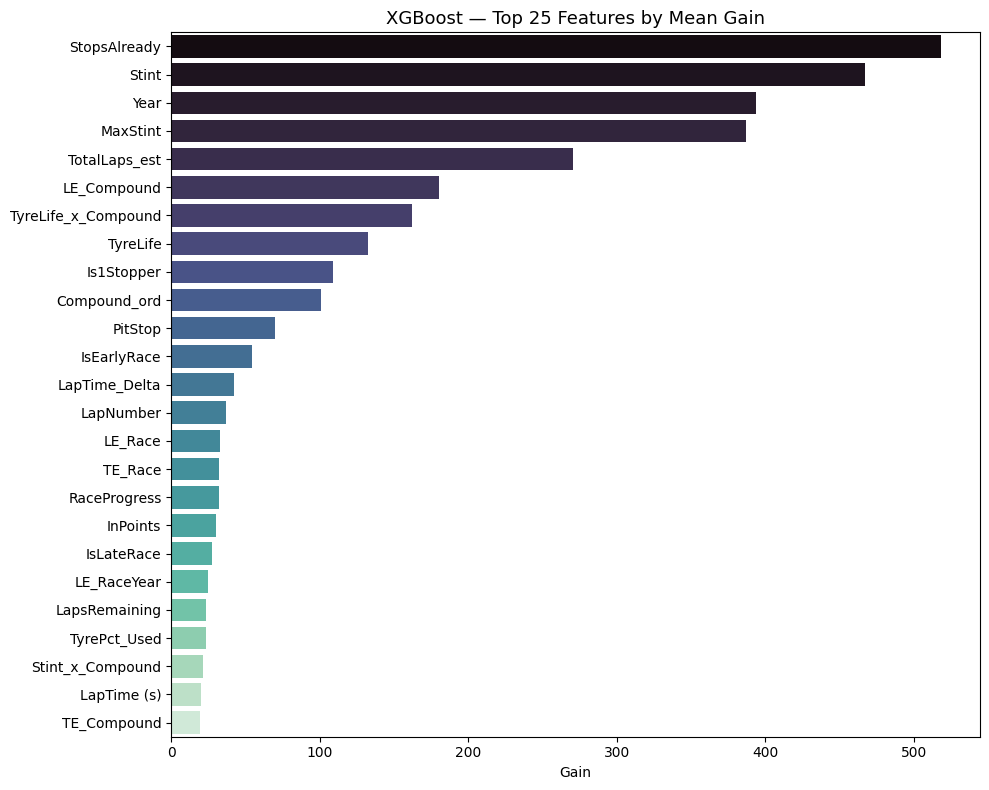


XGBoost training complete.
   OOF array  shape : (566799,)
   Test preds shape : (188165,)


In [26]:
oof_xgb  = np.zeros(len(X))
test_xgb = np.zeros(len(X_test))
fold_auc_xgb = []

print("=" * 60)
print(f"  XGBoost — {N_FOLDS}-Fold GroupKFold (by Year — one season per fold)")
print("=" * 60)

for fold, (tr_idx, val_idx) in enumerate(sgkf.split(X, y, groups), 1):

    X_tr, X_val = X[tr_idx], X[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]
    w_tr        = w[tr_idx]

    dtrain = xgb.DMatrix(X_tr, label=y_tr, weight=w_tr,
                         feature_names=FEATURES)
    dvalid = xgb.DMatrix(X_val, label=y_val,
                         feature_names=FEATURES)
    dtest  = xgb.DMatrix(X_test, feature_names=FEATURES)

    model = xgb.train(
        XGB_PARAMS,
        dtrain,
        num_boost_round      = 3000,
        evals                = [(dvalid, "val")],
        early_stopping_rounds= 100,
        verbose_eval         = 200,
    )

    oof_xgb[val_idx]  = model.predict(dvalid)
    test_xgb         += model.predict(dtest) / N_FOLDS

    auc = roc_auc_score(y_val, oof_xgb[val_idx])
    fold_auc_xgb.append(auc)
    print(f"\n  Fold {fold} │ AUC: {auc:.5f} │ "
          f"Best iter: {model.best_iteration}")

    del X_tr, X_val, y_tr, y_val, dtrain, dvalid, dtest
    gc.collect()

# OOF Score
oof_auc_xgb = roc_auc_score(y, oof_xgb)

print("\n" + "=" * 60)
print(f"  XGBoost OOF AUC : {oof_auc_xgb:.5f}")
print(f"  Per-fold AUCs   : {[round(a,5) for a in fold_auc_xgb]}")
print(f"  Std dev         : {np.std(fold_auc_xgb):.5f}")
print("=" * 60)

# Feature Importance Plot
fi_xgb = (
    pd.Series(model.get_score(importance_type="gain"))
    .sort_values(ascending=False)
    .head(25)
    .reset_index()
)
fi_xgb.columns = ["feature", "importance"]

plt.figure(figsize=(10, 8))
sns.barplot(data=fi_xgb, x="importance", y="feature", palette="mako")
plt.title("XGBoost — Top 25 Features by Mean Gain", fontsize=13)
plt.xlabel("Gain")
plt.ylabel("")
plt.tight_layout()
plt.show()

print("\nXGBoost training complete.")
print(f"   OOF array  shape : {oof_xgb.shape}")
print(f"   Test preds shape : {test_xgb.shape}")

# CatBoost

  CatBoost — 5-Fold GroupKFold (by Year — one season per fold)
  Cat features: ['LE_Driver', 'LE_Race', 'LE_Compound', 'LE_RaceYear']
0:	test: 0.7752351	best: 0.7752351 (0)	total: 556ms	remaining: 18m 31s
200:	test: 0.8845946	best: 0.8845946 (200)	total: 1m 21s	remaining: 12m 12s
400:	test: 0.9028790	best: 0.9029165 (397)	total: 2m 44s	remaining: 10m 57s
600:	test: 0.9082476	best: 0.9082476 (600)	total: 4m 6s	remaining: 9m 33s
800:	test: 0.9129960	best: 0.9131977 (780)	total: 5m 29s	remaining: 8m 13s
1000:	test: 0.9160242	best: 0.9162260 (966)	total: 6m 51s	remaining: 6m 50s
1200:	test: 0.9166755	best: 0.9169219 (1182)	total: 8m 13s	remaining: 5m 28s
1400:	test: 0.9167719	best: 0.9172212 (1355)	total: 9m 35s	remaining: 4m 5s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9172212188
bestIteration = 1355

Shrink model to first 1356 iterations.

  Fold 1 │ AUC: 0.91722 │ Best iter: 1355
0:	test: 0.7815329	best: 0.7815329 (0)	total: 442ms	remaining: 14m 43s
200:	test:

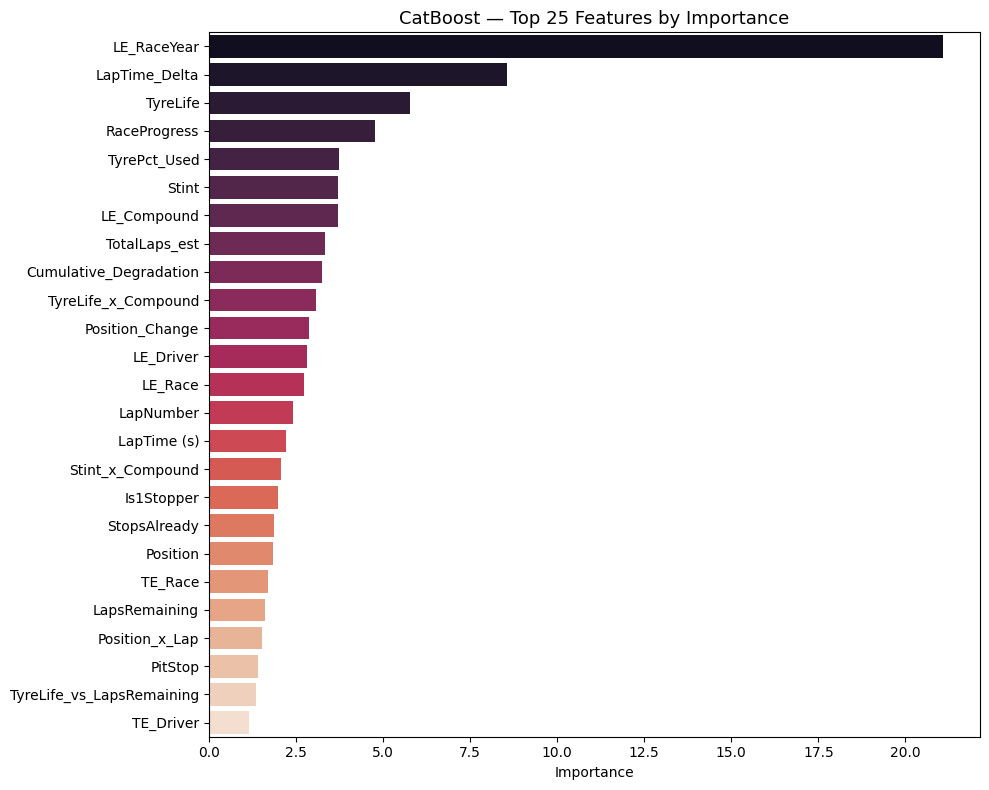


CatBoost training complete.
   OOF array  shape : (566799,)
   Test preds shape : (188165,)


In [27]:
# CatBoost rejects cat_features on float numpy arrays;
# passing a DataFrame lets it inspect column types correctly.
X_df      = train_fe[FEATURES].copy()
X_test_df = test_fe[FEATURES].copy()

# Cast LE columns to int (they're integers but may be stored as float)
LE_COLS_IN_FEATURES = ["LE_Driver", "LE_Race", "LE_Compound", "LE_RaceYear"]
for col in LE_COLS_IN_FEATURES:
    X_df[col]      = X_df[col].astype(int)
    X_test_df[col] = X_test_df[col].astype(int)

y_arr = train_fe[TARGET].values.astype(int)
w_arr = train_fe["sample_weight"].values
groups_arr = train_fe["RaceYear"].values

oof_cb      = np.zeros(len(X_df))
test_cb     = np.zeros(len(X_test_df))
fold_auc_cb = []

print("=" * 60)
print(f"  CatBoost — {N_FOLDS}-Fold GroupKFold (by Year — one season per fold)")
print(f"  Cat features: {LE_COLS_IN_FEATURES}")
print("=" * 60)

for fold, (tr_idx, val_idx) in enumerate(sgkf.split(X_df, y_arr, groups_arr), 1):

    X_tr  = X_df.iloc[tr_idx]
    X_val = X_df.iloc[val_idx]
    y_tr  = y_arr[tr_idx]
    y_val = y_arr[val_idx]
    w_tr  = w_arr[tr_idx]

    train_pool = Pool(
        X_tr, label=y_tr,
        weight=w_tr,
        cat_features=LE_COLS_IN_FEATURES,
    )
    valid_pool = Pool(
        X_val, label=y_val,
        cat_features=LE_COLS_IN_FEATURES,
    )
    test_pool = Pool(
        X_test_df,
        cat_features=LE_COLS_IN_FEATURES,
    )

    model = CatBoostClassifier(**CB_PARAMS)
    model.fit(
        train_pool,
        eval_set=valid_pool,
        use_best_model=True,
    )

    oof_cb[val_idx]  = model.predict_proba(valid_pool)[:, 1]
    test_cb         += model.predict_proba(test_pool)[:, 1] / N_FOLDS

    auc = roc_auc_score(y_val, oof_cb[val_idx])
    fold_auc_cb.append(auc)
    print(f"\n  Fold {fold} │ AUC: {auc:.5f} │ "
          f"Best iter: {model.best_iteration_}")

    del X_tr, X_val, y_tr, y_val, train_pool, valid_pool, test_pool
    gc.collect()

oof_auc_cb = roc_auc_score(y_arr, oof_cb)

print("\n" + "=" * 60)
print(f"  CatBoost OOF AUC : {oof_auc_cb:.5f}")
print(f"  Per-fold AUCs    : {[round(a,5) for a in fold_auc_cb]}")
print(f"  Std dev          : {np.std(fold_auc_cb):.5f}")
print("=" * 60)

fi_cb = (
    pd.DataFrame({
        "feature"   : FEATURES,
        "importance": model.get_feature_importance(),
    })
    .sort_values("importance", ascending=False)
    .head(25)
)

plt.figure(figsize=(10, 8))
sns.barplot(data=fi_cb, x="importance", y="feature", palette="rocket")
plt.title("CatBoost — Top 25 Features by Importance", fontsize=13)
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

print("\nCatBoost training complete.")
print(f"   OOF array  shape : {oof_cb.shape}")
print(f"   Test preds shape : {test_cb.shape}")

# MLP Neural Network

In [28]:
class PitStopMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(64, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.network(x).squeeze()

oof_mlp  = np.zeros(len(X))
test_mlp = np.zeros(len(X_test))
fold_auc_mlp = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print("=" * 60)
print(f"  MLP — {N_FOLDS}-Fold StratifiedGroupKFold (by RaceYear)")
print("=" * 60)

for fold, (tr_idx, val_idx) in enumerate(sgkf.split(X, y, groups), 1):

    X_tr_raw  = X[tr_idx]
    X_val_raw = X[val_idx]
    
    scaler = StandardScaler()
    X_tr  = scaler.fit_transform(X_tr_raw)
    X_val = scaler.transform(X_val_raw)
    X_test_scaled_fold = scaler.transform(X_test)
    
    y_tr  = y[tr_idx].astype(np.float32)
    y_val = y[val_idx].astype(np.float32)
    w_tr  = w[tr_idx].astype(np.float32)

    train_dataset = TensorDataset(
        torch.tensor(X_tr, dtype=torch.float32),
        torch.tensor(y_tr, dtype=torch.float32),
        torch.tensor(w_tr, dtype=torch.float32),
    )
    val_dataset = TensorDataset(
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.float32),
    )
    test_dataset = TensorDataset(
        torch.tensor(X_test_scaled_fold, dtype=torch.float32),
    )

    train_loader = DataLoader(train_dataset, batch_size=4096, shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=4096, shuffle=False)
    test_loader  = DataLoader(test_dataset,  batch_size=4096, shuffle=False)

    model_mlp = PitStopMLP(input_dim=X_tr.shape[1]).to(device)
    optimizer  = torch.optim.AdamW(model_mlp.parameters(), lr=1e-3, weight_decay=1e-5)
    criterion  = nn.BCELoss(reduction="none")
    scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(
                    optimizer, T_max=20, eta_min=1e-5)

    best_auc_mlp  = 0
    best_state    = None

    for epoch in range(20):
        model_mlp.train()
        for batch_x, batch_y, batch_w in train_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            batch_w = batch_w.to(device)
            optimizer.zero_grad()
            preds = model_mlp(batch_x)
            loss  = (criterion(preds, batch_y) * batch_w).mean()
            loss.backward()
            optimizer.step()
        scheduler.step()

        model_mlp.eval()
        val_preds = []
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x = batch_x.to(device)
                val_preds.extend(model_mlp(batch_x).cpu().numpy())

        auc = roc_auc_score(y_val, val_preds)
        if auc > best_auc_mlp:
            best_auc_mlp = auc
            best_state   = {k: v.clone() for k, v in model_mlp.state_dict().items()}

    model_mlp.load_state_dict(best_state)
    model_mlp.eval()

    val_preds_final = []
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x = batch_x.to(device)
            val_preds_final.extend(model_mlp(batch_x).cpu().numpy())
    oof_mlp[val_idx] = val_preds_final

    test_preds_fold = []
    with torch.no_grad():
        for (batch_x,) in test_loader:
            batch_x = batch_x.to(device)
            test_preds_fold.extend(model_mlp(batch_x).cpu().numpy())
    test_mlp += np.array(test_preds_fold) / N_FOLDS

    auc = roc_auc_score(y_val, oof_mlp[val_idx])
    fold_auc_mlp.append(auc)
    print(f"\n  Fold {fold} │ AUC: {auc:.5f} │ Best epoch AUC: {best_auc_mlp:.5f}")

    del model_mlp, train_dataset, val_dataset
    gc.collect()

oof_auc_mlp = roc_auc_score(y, oof_mlp)
print("\n" + "=" * 60)
print(f"  MLP OOF AUC : {oof_auc_mlp:.5f}")
print(f"  Per-fold    : {[round(a,5) for a in fold_auc_mlp]}")
print(f"  Std dev     : {np.std(fold_auc_mlp):.5f}")
print("=" * 60)
print("\nMLP training complete.")

Using device: cpu
  MLP — 5-Fold StratifiedGroupKFold (by RaceYear)

  Fold 1 │ AUC: 0.93919 │ Best epoch AUC: 0.93919

  Fold 2 │ AUC: 0.93302 │ Best epoch AUC: 0.93302

  Fold 3 │ AUC: 0.92789 │ Best epoch AUC: 0.92789

  Fold 4 │ AUC: 0.92799 │ Best epoch AUC: 0.92799

  Fold 5 │ AUC: 0.90134 │ Best epoch AUC: 0.90134

  MLP OOF AUC : 0.92461
  Per-fold    : [np.float64(0.93919), np.float64(0.93302), np.float64(0.92789), np.float64(0.92799), np.float64(0.90134)]
  Std dev     : 0.01295

MLP training complete.


# Model Comparison Table

In [29]:
print("\nModel Comparison")
comparison = pd.DataFrame({
    "Model"   : ["LightGBM", "XGBoost", "CatBoost", "MLP"],
    "OOF AUC" : [oof_auc_lgb, oof_auc_xgb, oof_auc_cb, oof_auc_mlp],
    "Std Dev" : [np.std(fold_auc), np.std(fold_auc_xgb), np.std(fold_auc_cb), np.std(fold_auc_mlp)],
})
print(comparison.to_string(index=False))


Model Comparison
   Model  OOF AUC  Std Dev
LightGBM   0.9344   0.0148
 XGBoost   0.9321   0.0158
CatBoost   0.9067   0.0150
     MLP   0.9246   0.0130


# Ensemble

In [30]:
def rank_norm(arr):
    """Map predictions to [0,1] via rank normalization."""
    return rankdata(arr) / len(arr)

oof_lgb_r  = rank_norm(oof_lgb)
oof_xgb_r  = rank_norm(oof_xgb)
oof_cb_r   = rank_norm(oof_cb)
oof_mlp_r  = rank_norm(oof_mlp)

test_lgb_r  = rank_norm(test_lgb)
test_xgb_r  = rank_norm(test_xgb)
test_cb_r   = rank_norm(test_cb)
test_mlp_r  = rank_norm(test_mlp)

print("Searching for optimal ensemble weights...")

best_auc    = 0
best_w      = (0.25, 0.25, 0.25, 0.25)
results     = []

for w_lgb in np.arange(0.1, 0.7, 0.05):
    for w_xgb in np.arange(0.05, 0.5, 0.05):
        for w_mlp in np.arange(0.05, 0.4, 0.05):
            w_cb = 1.0 - w_lgb - w_xgb - w_mlp
            if w_cb < 0.05 or w_cb > 0.6:
                continue
            blend = (w_lgb * oof_lgb_r + w_xgb * oof_xgb_r +
                     w_cb  * oof_cb_r  + w_mlp * oof_mlp_r)
            auc   = roc_auc_score(y_arr, blend)
            results.append((auc, w_lgb, w_xgb, w_cb, w_mlp))
            if auc > best_auc:
                best_auc = auc
                best_w   = (w_lgb, w_xgb, w_cb, w_mlp)

w_lgb_opt, w_xgb_opt, w_cb_opt, w_mlp_opt = best_w

print(f"\nEnsemble Weight Search Results")
print(f"  Best OOF AUC  : {best_auc:.5f}")
print(f"  LightGBM weight : {w_lgb_opt:.2f}")
print(f"  XGBoost  weight : {w_xgb_opt:.2f}")
print(f"  CatBoost weight : {w_cb_opt:.2f}")
print(f"  MLP      weight : {w_mlp_opt:.2f}")

equal_blend_oof = (oof_lgb_r + oof_xgb_r + oof_cb_r + oof_mlp_r) / 4
equal_auc       = roc_auc_score(y_arr, equal_blend_oof)
print(f"\n  Equal weights OOF AUC  : {equal_auc:.5f}")
print(f"  Optimal weights OOF AUC: {best_auc:.5f}")
print(f"  Gain from optimization : {best_auc - equal_auc:+.5f}")

final_preds = (
    w_lgb_opt * test_lgb_r +
    w_xgb_opt * test_xgb_r +
    w_cb_opt  * test_cb_r  +
    w_mlp_opt * test_mlp_r
)

Searching for optimal ensemble weights...

Ensemble Weight Search Results
  Best OOF AUC  : 0.93505
  LightGBM weight : 0.65
  XGBoost  weight : 0.10
  CatBoost weight : 0.10
  MLP      weight : 0.15

  Equal weights OOF AUC  : 0.93384
  Optimal weights OOF AUC: 0.93505
  Gain from optimization : +0.00120


# Final Results and Submission


Submission Stats
  Shape         : (188165, 2)
  Pred min      : 0.00035
  Pred max      : 0.99998
  Pred mean     : 0.50000

Final Model Summary
             Model  OOF AUC Weight
          LightGBM   0.9344 0.6500
           XGBoost   0.9321 0.1000
          CatBoost   0.9067 0.1000
               MLP   0.9246 0.1500
Ensemble (optimal)   0.9350      —
  Ensemble (equal)   0.9338      —


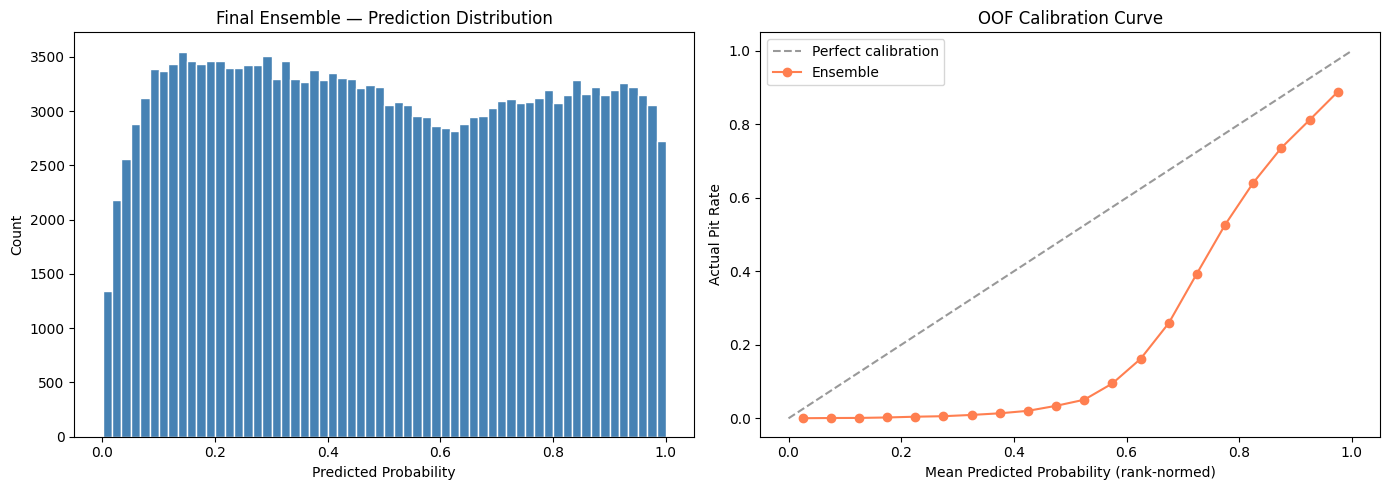


Submission saved to /kaggle/working/submission.csv


In [31]:
test_fe_copy = test_fe[["id"]].copy()
test_fe_copy["PitNextLap"] = final_preds
sub = test_fe_copy.sort_values("id").reset_index(drop=True)
sub.to_csv("/kaggle/working/submission.csv", index=False)

print(f"\nSubmission Stats")
print(f"  Shape         : {sub.shape}")
print(f"  Pred min      : {final_preds.min():.5f}")
print(f"  Pred max      : {final_preds.max():.5f}")
print(f"  Pred mean     : {final_preds.mean():.5f}")

print(f"\nFinal Model Summary")
summary = pd.DataFrame({
    "Model"   : ["LightGBM", "XGBoost", "CatBoost", "MLP",
                 "Ensemble (optimal)", "Ensemble (equal)"],
    "OOF AUC" : [oof_auc_lgb, oof_auc_xgb, oof_auc_cb, oof_auc_mlp,
                 best_auc, equal_auc],
    "Weight"  : [w_lgb_opt, w_xgb_opt, w_cb_opt, w_mlp_opt, "—", "—"],
})
print(summary.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(final_preds, bins=60, color="steelblue", edgecolor="white")
axes[0].set_title("Final Ensemble — Prediction Distribution")
axes[0].set_xlabel("Predicted Probability")
axes[0].set_ylabel("Count")

bins      = np.linspace(0, 1, 21)
bin_idx   = np.digitize(rank_norm(
    w_lgb_opt * oof_lgb_r + w_xgb_opt * oof_xgb_r + w_cb_opt * oof_cb_r
), bins)
bin_pred  = [rank_norm(w_lgb_opt*oof_lgb_r + w_xgb_opt*oof_xgb_r + w_cb_opt*oof_cb_r
                       )[bin_idx==i].mean() for i in range(1, len(bins))]
bin_actual= [y_arr[bin_idx==i].mean() for i in range(1, len(bins))]

axes[1].plot([0,1],[0,1], "k--", alpha=0.4, label="Perfect calibration")
axes[1].plot(bin_pred, bin_actual, "o-", color="coral", label="Ensemble")
axes[1].set_title("OOF Calibration Curve")
axes[1].set_xlabel("Mean Predicted Probability (rank-normed)")
axes[1].set_ylabel("Actual Pit Rate")
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nSubmission saved to /kaggle/working/submission.csv")